# Results
Aggregated analysis and figures for the paper.
Requires `results/fever_results.csv` and `results/hotpotqa_results.csv` (produced by notebooks 04 and 05).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path

from nb_style import MODEL_LABELS, MODEL_COLORS, PROMPT_COLORS, PROMPT_COLORS_QA

RESULTS_DIR = Path("../results")
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(exist_ok=True)

fever = pd.read_csv(RESULTS_DIR / "fever_results.csv")
hpqa  = pd.read_csv(RESULTS_DIR / "hotpotqa_results.csv")
print("FEVER rows:", len(fever))
print("HotpotQA rows:", len(hpqa))
fever.head()

FEVER rows: 12
HotpotQA rows: 12


,model,prompt_type,poison_rate,accuracy,macro_f1,hallucination_rate,contradiction_detection_rate
0,Qwen/Qwen3.5-2B,standard,0,0.640000,0.625749,0.576923,NaN
1,Qwen/Qwen3.5-2B,standard,1,0.586667,0.584049,0.423077,NaN
2,Qwen/Qwen3.5-2B,chain_of_thought,0,0.560000,0.532846,0.115385,NaN
3,Qwen/Qwen3.5-2B,chain_of_thought,1,0.413333,0.363564,0.230769,NaN
4,Qwen/Qwen3.5-2B,vigilant,0,0.453333,0.412960,0.884615,0.0


## FEVER Results

In [2]:
PROMPT_LABELS = {
    "standard":         "Standard",
    "chain_of_thought": "CoT",
    "vigilant":         "Vigilant",
}

fever["model_label"]  = fever["model"].map(MODEL_LABELS)
fever["prompt_label"] = fever["prompt_type"].map(PROMPT_LABELS)

pivot_acc = (
    fever
    .pivot_table(index=["model_label", "prompt_label"],
                 columns="poison_rate", values="accuracy")
    .rename(columns={0: "r=0 (clean)", 1: "r=1 (poisoned)"})
)
pivot_acc["delta"] = pivot_acc["r=1 (poisoned)"] - pivot_acc["r=0 (clean)"]
print("=== FEVER — Accuracy ===\n")
print(pivot_acc.round(3).to_string())

=== FEVER — Accuracy ===

poison_rate               r=0 (clean)  r=1 (poisoned)  delta
model_label prompt_label                                    
Gemma-4     CoT                 0.480           0.440 -0.040
            Standard            0.573           0.467 -0.107
            Vigilant            0.520           0.467 -0.053
Qwen3.5     CoT                 0.560           0.413 -0.147
            Standard            0.640           0.587 -0.053
            Vigilant            0.453           0.413 -0.040


In [3]:
pivot_f1 = (
    fever
    .pivot_table(index=["model_label", "prompt_label"],
                 columns="poison_rate", values="macro_f1")
    .rename(columns={0: "r=0 (clean)", 1: "r=1 (poisoned)"})
)
pivot_f1["delta"] = pivot_f1["r=1 (poisoned)"] - pivot_f1["r=0 (clean)"]
print("=== FEVER — Macro-F1 ===\n")
print(pivot_f1.round(3).to_string())

=== FEVER — Macro-F1 ===

poison_rate               r=0 (clean)  r=1 (poisoned)  delta
model_label prompt_label                                    
Gemma-4     CoT                 0.475           0.373 -0.102
            Standard            0.539           0.432 -0.106
            Vigilant            0.483           0.415 -0.067
Qwen3.5     CoT                 0.533           0.364 -0.169
            Standard            0.626           0.584 -0.042
            Vigilant            0.413           0.400 -0.013


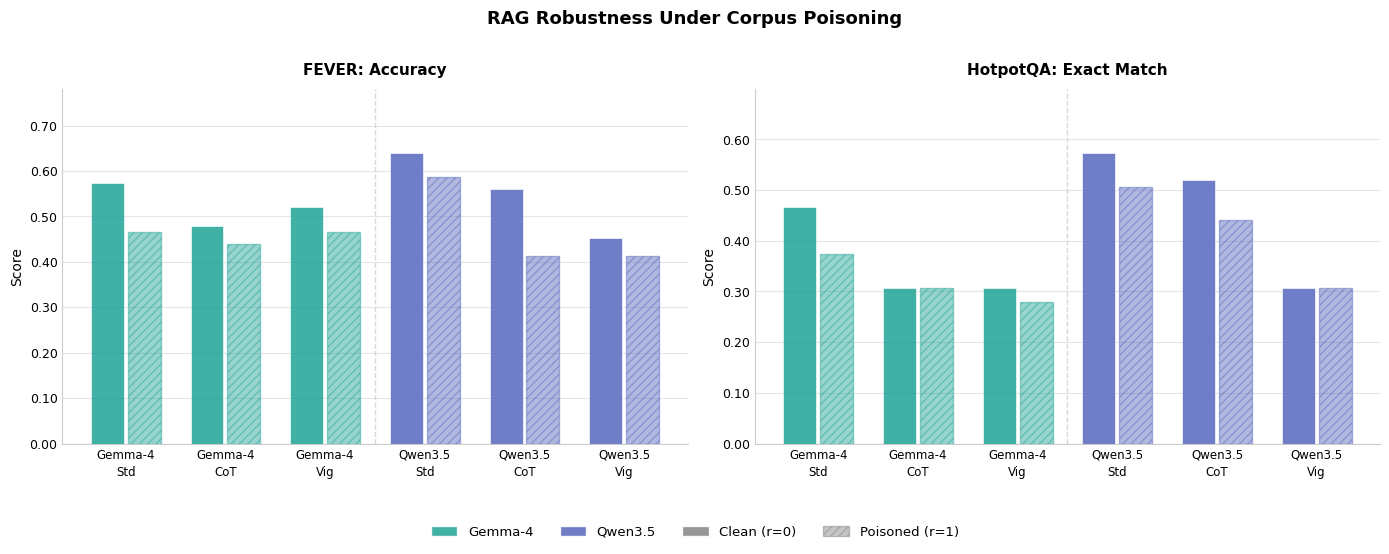

In [4]:

# ── Combined robustness figure (paper figure) ─────────────────────────────────
import matplotlib.patches as mpatches

PROMPT_SHORT = {
    "standard": "Std", "chain_of_thought": "CoT", "vigilant": "Vig",
    "standard_qa": "Std", "cot_qa": "CoT", "vigilant_qa": "Vig",
}

FEVER_CONDS = [
    ("google/gemma-4-E2B-it", "standard"),
    ("google/gemma-4-E2B-it", "chain_of_thought"),
    ("google/gemma-4-E2B-it", "vigilant"),
    ("Qwen/Qwen3.5-2B",       "standard"),
    ("Qwen/Qwen3.5-2B",       "chain_of_thought"),
    ("Qwen/Qwen3.5-2B",       "vigilant"),
]
HPQA_CONDS = [
    ("google/gemma-4-E2B-it", "standard_qa"),
    ("google/gemma-4-E2B-it", "cot_qa"),
    ("google/gemma-4-E2B-it", "vigilant_qa"),
    ("Qwen/Qwen3.5-2B",       "standard_qa"),
    ("Qwen/Qwen3.5-2B",       "cot_qa"),
    ("Qwen/Qwen3.5-2B",       "vigilant_qa"),
]

BAR_W   = 0.33
GAP     = 0.04
ALPHA_C = 0.88
ALPHA_P = 0.48
HATCH   = "////"
GRID_C  = "#e5e5e5"
SPINE_C = "#cccccc"

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
fig.patch.set_facecolor("white")

panels = [
    (axes[0], FEVER_CONDS, fever, "accuracy",    "FEVER: Accuracy"),
    (axes[1], HPQA_CONDS,  hpqa,  "exact_match", "HotpotQA: Exact Match"),
]

for ax, conds, df, metric, title in panels:
    x    = np.arange(len(conds))
    ymax = df[metric].max()

    for i, (model, prompt) in enumerate(conds):
        color = MODEL_COLORS[model]
        r0 = df[(df.model == model) & (df.prompt_type == prompt) & (df.poison_rate == 0)][metric].values[0]
        r1 = df[(df.model == model) & (df.prompt_type == prompt) & (df.poison_rate == 1)][metric].values[0]

        ax.bar(x[i] - BAR_W/2 - GAP/2, r0, BAR_W,
               color=color, alpha=ALPHA_C, edgecolor="white", linewidth=0.5, zorder=3)
        ax.bar(x[i] + BAR_W/2 + GAP/2, r1, BAR_W,
               color=color, alpha=ALPHA_P, edgecolor=color, linewidth=1.0,
               hatch=HATCH, zorder=3)

    ax.set_facecolor("white")
    ax.yaxis.grid(True, color=GRID_C, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    ax.spines["left"].set_color(SPINE_C)
    ax.spines["bottom"].set_color(SPINE_C)
    ax.tick_params(length=0, labelsize=9)

    xlabels = [f"{MODEL_LABELS[m]}\n{PROMPT_SHORT[p]}" for m, p in conds]
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, fontsize=8.5, linespacing=1.4)
    ax.set_ylim(0, min(ymax * 1.22, 1.0))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.set_ylabel("Score", fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="semibold", pad=10)

    ax.axvline(2.5, color="#c8c8c8", linewidth=1.0, linestyle="--", zorder=2, alpha=0.7)

patches = [
    mpatches.Patch(facecolor=MODEL_COLORS["google/gemma-4-E2B-it"], alpha=ALPHA_C,
                   edgecolor="white", label="Gemma-4"),
    mpatches.Patch(facecolor=MODEL_COLORS["Qwen/Qwen3.5-2B"], alpha=ALPHA_C,
                   edgecolor="white", label="Qwen3.5"),
    mpatches.Patch(facecolor="#888888", alpha=ALPHA_C, edgecolor="white",
                   label="Clean (r=0)"),
    mpatches.Patch(facecolor="#888888", alpha=ALPHA_P, edgecolor="#888888",
                   hatch=HATCH, label="Poisoned (r=1)"),
]
fig.legend(handles=patches, loc="lower center", ncol=4,
           frameon=False, fontsize=9.5, bbox_to_anchor=(0.5, -0.03))

fig.suptitle("RAG Robustness Under Corpus Poisoning",
             fontsize=13, fontweight="bold", y=1.01)
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig(FIGURES_DIR / "combined_robustness.pdf", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "combined_robustness.png", bbox_inches="tight", dpi=200)
plt.show()


In [5]:
# Hallucination rate comparison
pivot_hal = (
    fever
    .pivot_table(index=["model_label", "prompt_label"],
                 columns="poison_rate", values="hallucination_rate")
    .rename(columns={0: "r=0", 1: "r=1"})
)
pivot_hal["delta"] = pivot_hal["r=1"] - pivot_hal["r=0"]
print("=== FEVER — Hallucination Rate ===\n")
print(pivot_hal.round(3).to_string())

=== FEVER — Hallucination Rate ===

poison_rate                 r=0    r=1  delta
model_label prompt_label                     
Gemma-4     CoT           0.308  0.077 -0.231
            Standard      0.808  0.846  0.038
            Vigilant      0.154  0.077 -0.077
Qwen3.5     CoT           0.115  0.231  0.115
            Standard      0.577  0.423 -0.154
            Vigilant      0.885  0.769 -0.115


## HotpotQA Results

In [6]:
PROMPT_LABELS_QA = {
    "standard_qa": "Standard",
    "cot_qa":      "CoT",
    "vigilant_qa": "Vigilant",
}

hpqa["model_label"]  = hpqa["model"].map(MODEL_LABELS)
hpqa["prompt_label"] = hpqa["prompt_type"].map(PROMPT_LABELS_QA)

pivot_em = (
    hpqa
    .pivot_table(index=["model_label", "prompt_label"],
                 columns="poison_rate", values="exact_match")
    .rename(columns={0: "r=0 (clean)", 1: "r=1 (poisoned)"})
)
pivot_em["delta"] = pivot_em["r=1 (poisoned)"] - pivot_em["r=0 (clean)"]
print("=== HotpotQA — Exact Match ===\n")
print(pivot_em.round(3).to_string())

pivot_tf1 = (
    hpqa
    .pivot_table(index=["model_label", "prompt_label"],
                 columns="poison_rate", values="token_f1")
    .rename(columns={0: "r=0 (clean)", 1: "r=1 (poisoned)"})
)
pivot_tf1["delta"] = pivot_tf1["r=1 (poisoned)"] - pivot_tf1["r=0 (clean)"]
print("\n=== HotpotQA — Token F1 ===\n")
print(pivot_tf1.round(3).to_string())

=== HotpotQA — Exact Match ===

poison_rate               r=0 (clean)  r=1 (poisoned)  delta
model_label prompt_label                                    
Gemma-4     CoT                 0.307           0.307  0.000
            Standard            0.467           0.373 -0.093
            Vigilant            0.307           0.280 -0.027
Qwen3.5     CoT                 0.520           0.440 -0.080
            Standard            0.573           0.507 -0.067
            Vigilant            0.307           0.307  0.000

=== HotpotQA — Token F1 ===

poison_rate               r=0 (clean)  r=1 (poisoned)  delta
model_label prompt_label                                    
Gemma-4     CoT                 0.465           0.423 -0.042
            Standard            0.580           0.536 -0.044
            Vigilant            0.511           0.421 -0.090
Qwen3.5     CoT                 0.655           0.568 -0.088
            Standard            0.684           0.606 -0.079
            Vigilant   